In [85]:
import numpy as np
import pandas as pd

In [86]:
data = pd.read_csv('spam.csv', encoding='latin-1', on_bad_lines='skip')

In [87]:
data

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [88]:
## data cleaning###

#  dropping the last theree collumns based on the data 

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [89]:
data=data.drop(columns=['Unnamed: 2','Unnamed: 3', 'Unnamed: 4'])

In [90]:
data

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [91]:
data=data.rename(columns={'v1':'SMS_Category',
                          'v2':'SMS_text'})

In [92]:
from sklearn.preprocessing import LabelEncoder

In [93]:
encoder=LabelEncoder()

In [94]:
data['SMS_Category']=encoder.fit_transform(data['SMS_Category'])

In [95]:
data

,SMS_Category,SMS_text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [96]:
data.isnull().sum()

SMS_Category    0
SMS_text        0
dtype: int64

In [97]:
data.duplicated().sum()
data=data.drop_duplicates(keep='first')


In [98]:
import matplotlib.pyplot as plt


In [99]:
# Doing EDA to check the data

counts=data['SMS_Category'].value_counts()
counts

SMS_Category
0    4516
1     653
Name: count, dtype: int64

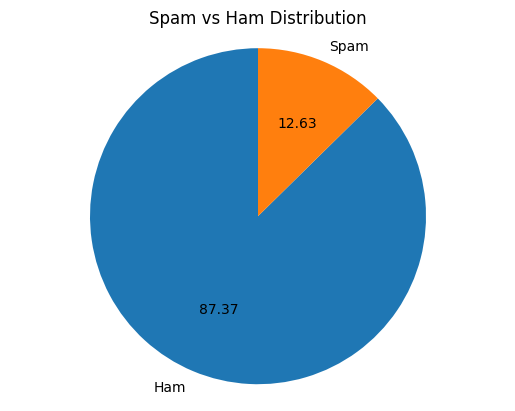

In [100]:
plt.pie(

counts,
labels=['Ham','Spam'],
autopct="%0.2f",
startangle=90
)

plt.axis('equal')
plt.title("Spam vs Ham Distribution")
plt.show()

In [101]:
data['Num_char']=data['SMS_text'].apply(len)

C:\Users\129mu\AppData\Local\Temp\ipykernel_1120\45155494.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Num_char']=data['SMS_text'].apply(len)


In [102]:
data

,SMS_Category,SMS_text,Num_char
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161
5568,0,Will Ì_ b going to esplanade fr home?,37
5569,0,"Pity, * was in mood for that. So...any other s...",57
5570,0,The guy did some bitching but I acted like i'd...,125


In [103]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\129mu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\129mu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\129mu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [104]:
# num of words 
data['num_words']=data['SMS_text'].apply(lambda x:len(nltk.word_tokenize(x)))

C:\Users\129mu\AppData\Local\Temp\ipykernel_1120\928914340.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['num_words']=data['SMS_text'].apply(lambda x:len(nltk.word_tokenize(x)))


In [105]:
data

,SMS_Category,SMS_text,Num_char,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15
...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35
5568,0,Will Ì_ b going to esplanade fr home?,37,9
5569,0,"Pity, * was in mood for that. So...any other s...",57,15
5570,0,The guy did some bitching but I acted like i'd...,125,27


In [106]:
data['num_sentences']=data['SMS_text'].apply(lambda x:len(nltk.sent_tokenize(x)))

C:\Users\129mu\AppData\Local\Temp\ipykernel_1120\4261433754.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['num_sentences']=data['SMS_text'].apply(lambda x:len(nltk.sent_tokenize(x)))


In [107]:
data[['Num_char','num_words','num_sentences']].describe()

,Num_char,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [108]:
# categorial description for HAM messages 
data[data["SMS_Category"]==0] [['Num_char','num_words','num_sentences']].describe()

,Num_char,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [109]:
# categorial description for spAM messages 
data[data["SMS_Category"]==1] [['Num_char','num_words','num_sentences']].describe()

,Num_char,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_words', ylabel='Count'>

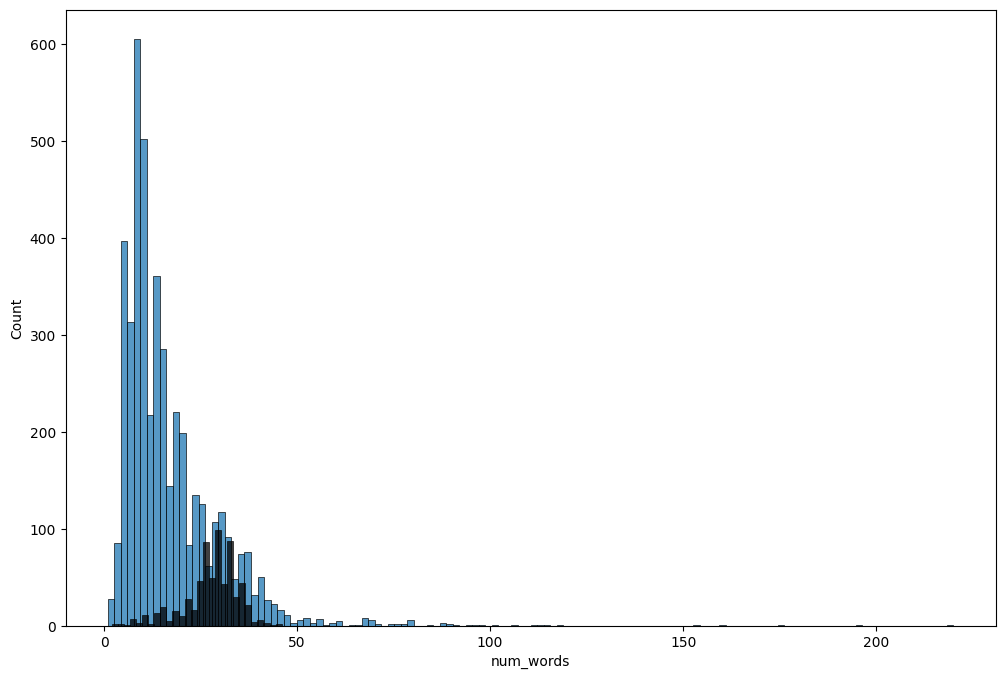

In [110]:
# analyzing the words used for spam and ham using histogram

import seaborn as sns 
plt.figure(figsize=(12,8))

sns.histplot(data[data["SMS_Category"]==0]['num_words'])
sns.histplot(data[data["SMS_Category"]==1]['num_words'],color='black')






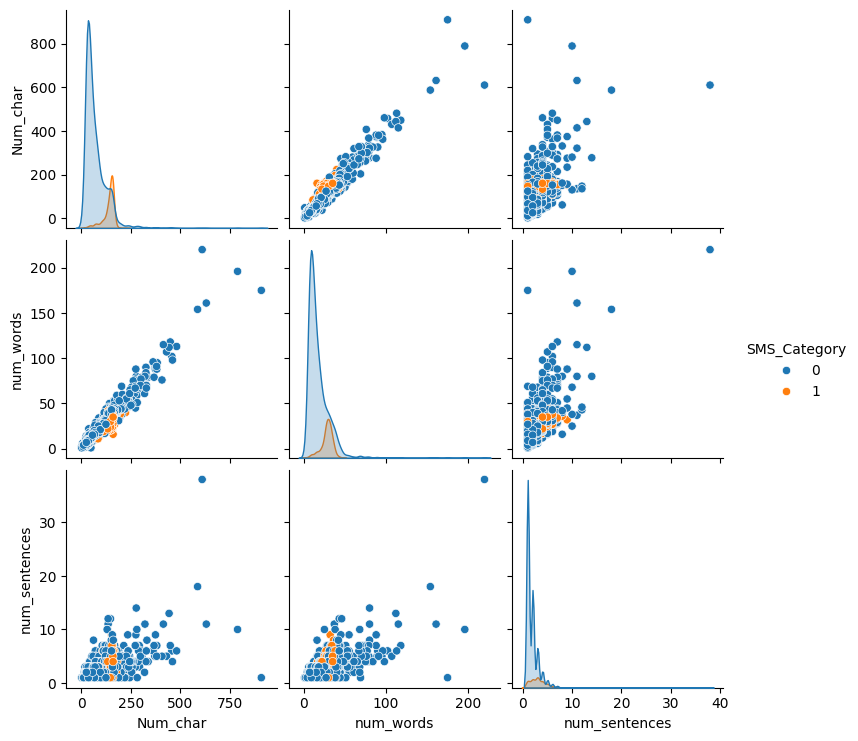

In [111]:
sns.pairplot(data,hue='SMS_Category')

<Axes: >

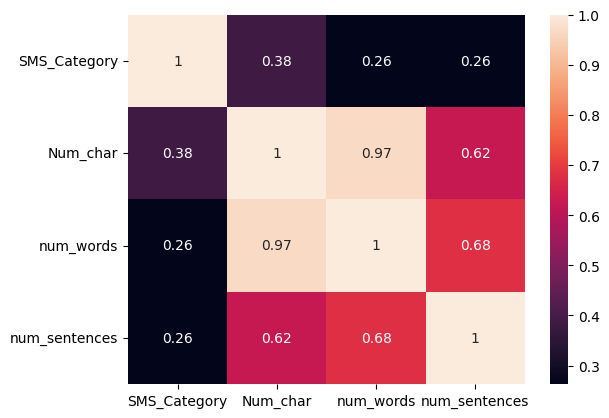

In [112]:
sns.heatmap(data.select_dtypes(include='number').corr(), annot=True)

In [113]:
from nltk.corpus import stopwords
import string
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

In [114]:
def transform_text(text):
    text=text.lower()
    text=nltk.word_tokenize(text)

    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)

    text=y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text=y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    

    return " ".join(y)




In [115]:
print(transform_text(data['SMS_text'][10]))

gon na home soon want talk stuff anymor tonight k cri enough today


In [116]:
data['SMS_text'][10]

"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

In [117]:
data['transformed_text']=data['SMS_text'].apply(transform_text)

C:\Users\129mu\AppData\Local\Temp\ipykernel_1120\2486445156.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['transformed_text']=data['SMS_text'].apply(transform_text)


In [118]:
data

,SMS_Category,SMS_text,Num_char,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though
...,...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4,2nd time tri 2 contact u pound prize 2 claim e...
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1,b go esplanad fr home
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2,piti mood suggest
5570,0,The guy did some bitching but I acted like i'd...,125,27,1,guy bitch act like interest buy someth els nex...


In [119]:
import sys
!{sys.executable} -m pip install wordcloud


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [120]:
from wordcloud import WordCloud

In [121]:
wc=WordCloud(width=500,height=500,min_font_size=10,background_color='red')

In [122]:
spam_wc=wc.generate(data[data['SMS_Category']==1]['transformed_text'].str.cat(sep=" "))

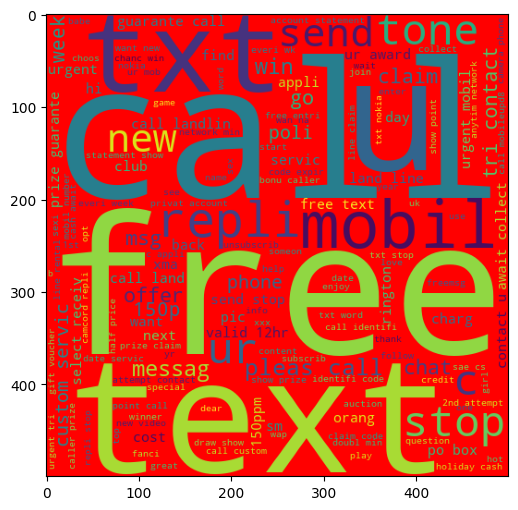

In [123]:
plt.figure(figsize=(18,6))
plt.imshow(spam_wc)

In [124]:
ham_wc=wc.generate(data[data['SMS_Category']==0]['transformed_text'].str.cat(sep=" "))

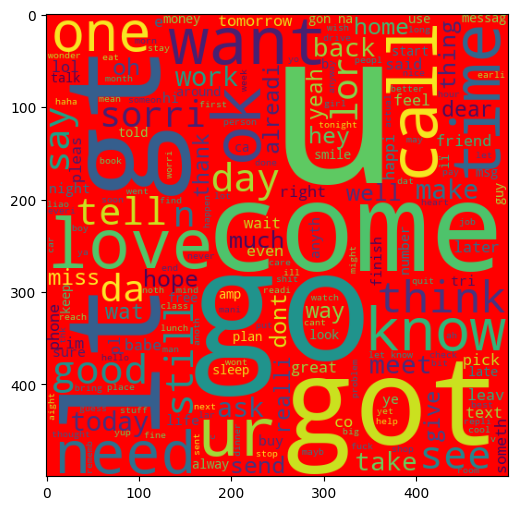

In [125]:
plt.figure(figsize=(18,6))
plt.imshow(ham_wc)

In [126]:
spam_corpus=[]

for msg in data[data['SMS_Category']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)
        

In [127]:
len(spam_corpus)

9939

In [128]:
from collections import Counter

In [129]:
words_data=pd.DataFrame(Counter(spam_corpus).most_common(30))

In [130]:
words_data = words_data.rename(columns={0: 'Words', 1: 'words_count'})

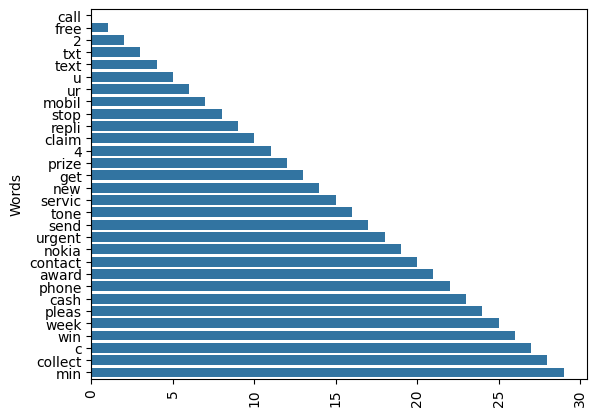

In [131]:
sns.barplot(words_data['Words'])
plt.xticks(rotation='vertical')
plt.show()

In [132]:
ham_corpus=[]

for msg in data[data['SMS_Category']==0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

len(ham_corpus)

35404

In [133]:
ham_words_data=pd.DataFrame(Counter(ham_corpus).most_common(30))

In [134]:
ham_words_data = ham_words_data.rename(columns={0: 'Words', 1: 'words_count'})

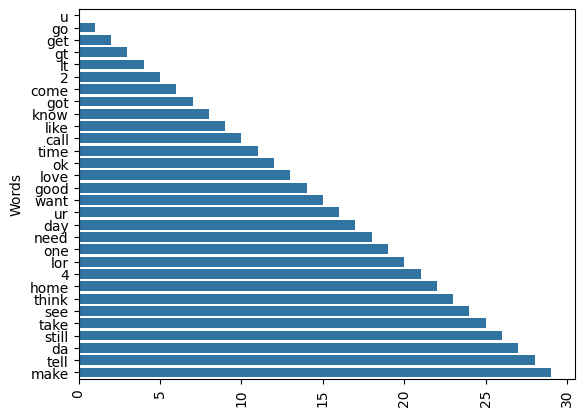

In [135]:
sns.barplot(ham_words_data['Words'])
plt.xticks(rotation='vertical')
plt.show()

In [136]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer

# cv=CountVectorizer()
cv2=TfidfVectorizer(ngram_range=(1,2), stop_words='english', max_features=5000)

In [137]:
# x=cv.fit_transform(data['transformed_text']).toarray()
x2=cv2.fit_transform(data["transformed_text"]).toarray()

In [138]:
# x.shape

In [139]:
y=data["SMS_Category"]

In [140]:
y

0       0
1       0
2       1
3       0
4       0
       ..
5567    1
5568    0
5569    0
5570    0
5571    0
Name: SMS_Category, Length: 5169, dtype: int64

In [141]:
from sklearn.model_selection import train_test_split

In [142]:
# x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [143]:
from sklearn.naive_bayes import GaussianNB,BernoulliNB,MultinomialNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [144]:
x_train,x_test,y_train,y_test=train_test_split(x2,y,test_size=0.2,random_state=42)


In [145]:
gnb=GaussianNB()
bnb=BernoulliNB()
mlnb=MultinomialNB(alpha=0.5)


In [146]:
# gnb.fit(x_train,y_train)
# y_pred1=gnb.predict(x_test)
# print(accuracy_score(y_test,y_pred1))
# print(confusion_matrix(y_test,y_pred1))
# print(precision_score(y_test,y_pred1))

In [147]:
mlnb.fit(x_train,y_train)
y_pred2=mlnb.predict(x_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9777562862669246
[[888   1]
 [ 22 123]]
0.9919354838709677


In [148]:
# bnb.fit(x_train,y_train)
# y_pred3=bnb.predict(x_test)
# print(accuracy_score(y_test,y_pred3))
# print(confusion_matrix(y_test,y_pred3))
# print(precision_score(y_test,y_pred3))

In [149]:
# with TfidfVectorizer

x_train,x_test,y_train,y_test=train_test_split(x2,y,test_size=0.2,random_state=42)


In [150]:
# gnb.fit(x_train,y_train)
# y_pred1=gnb.predict(x_test)
# print(accuracy_score(y_test,y_pred1))
# print(confusion_matrix(y_test,y_pred1))
# print(precision_score(y_test,y_pred1))

In [151]:
mlnb.fit(x_train,y_train)
y_pred2=mlnb.predict(x_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9777562862669246
[[888   1]
 [ 22 123]]
0.9919354838709677


In [152]:
# bnb.fit(x_train,y_train)
# y_pred3=bnb.predict(x_test)
# print(accuracy_score(y_test,y_pred3))
# print(confusion_matrix(y_test,y_pred3))
# print(precision_score(y_test,y_pred3))

In [153]:
# applying scaling to the tdif vectorization model of Multi binomial naive bayes model scaling drops the precision score .

In [154]:
#  for this problem you can also use other classification models like knn random forest xgboost svc etc adboost logistic 
# but from the comparison amongst all NB has the best precision and accuracy score as well confusion matrix


In [155]:
# taking 2 more best algorithims like svc and etc for the comparisoon

from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier

In [ ]:
support_vect=SVC(kernel='sigmoid',gamma=1.0,probability=True)
etc=ExtraTreesClassifier(n_estimators=50,random_state=2)

In [157]:
from sklearn.ensemble import VotingClassifier

In [158]:
voting=VotingClassifier(estimators=[('svm',support_vect),('nb',mlnb),('et',etc)],voting='soft')

In [159]:
voting.fit(x_train,y_train,)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('svm', ...), ('nb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'sigmoid'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",1.0
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0


In [160]:
y_pred4=voting.predict(x_test)
print(accuracy_score(y_test,y_pred4))
print(precision_score(y_test,y_pred4))

0.9825918762088974
0.9922480620155039


In [161]:
print(confusion_matrix(y_test,y_pred4))


[[888   1]
 [ 17 128]]


In [162]:
# applying stacking on three different models to check the accuracy and precision of the model

# from sklearn.ensemble import StackingClassifier
# from sklearn.ensemble import RandomForestClassifier

In [163]:
# applying stacking on three different models to check the accuracy and precision of the model


# estimators=[('svm',support_vect),('nb',mlnb),('et',etc)]
# final_estimator=RandomForestClassifier()


In [164]:
# clf=StackingClassifier(estimators=estimators,final_estimator=final_estimator)

In [165]:
# clf.fit(x_train,y_train)

In [166]:
# y_pred_clf=clf.predict(x_test)

In [167]:
# print(accuracy_score(y_test,y_pred_clf))
# print(precision_score(y_test,y_pred_clf))    # using the stacking concept reduces the precision count so stacking is not a vital approach

In [168]:
import pickle

pickle.dump(cv2, open("vectorizer.pkl","wb"))
pickle.dump(mlnb, open("model.pkl", "wb"))